Training RMSE Table of Polynomial Degree (0)
Training RMSE Table of Polynomial Degree (1)
Training RMSE Table of Polynomial Degree (3)
Training RMSE Table of Polynomial Degree (9)
--------------------
Polynomial Degree (M)	Training RMSE
0			0.6720
1			0.5153
3			0.0847
9			0.0000


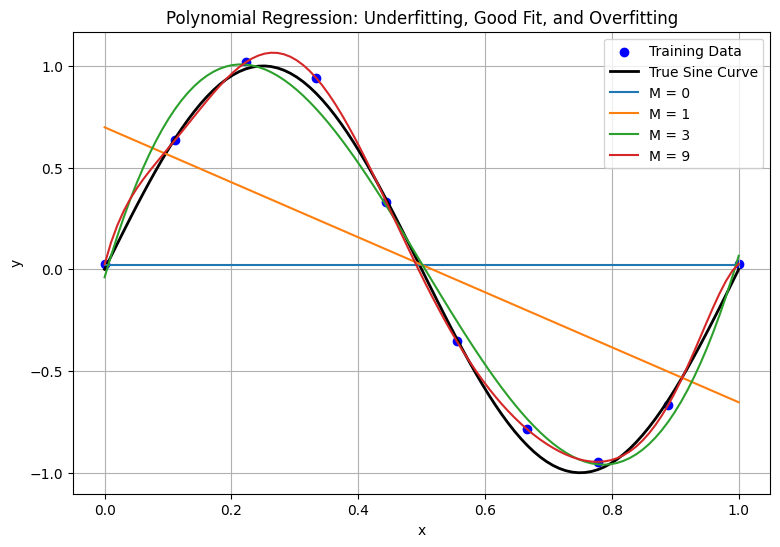

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# For reproducibility
np.random.seed(42)

# Step A & B: Training data
N = 10
x_train = np.linspace(0, 1, N).reshape(-1, 1)

# Step C: Noisy outputs
y_true = np.sin(2 * np.pi * x_train)
noise = np.random.normal(0, 0.05, size=(N, 1))
y_train = y_true + noise

# Clean test data (for true curve only)
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test = np.sin(2 * np.pi * x_test)

degrees = [0, 1, 3, 9]
models = {}
predictions = {}
rmse_values = {}

for M in degrees:
    poly = PolynomialFeatures(degree=M, include_bias=True)
    
    x_train_poly = poly.fit_transform(x_train)
    
    model = LinearRegression()
    model.fit(x_train_poly, y_train)
    
    # Store model and transformer
    models[M] = (model, poly)
    
    # Training RMSE
    y_train_pred = model.predict(x_train_poly)
    rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_values[M] = rmse
    
    # Predictions on clean test data
    X_test_poly = poly.transform(x_test)
    predictions[M] = model.predict(X_test_poly)
    
    
    print(f"Training RMSE Table of Polynomial Degree ({M})")
print("--------------------")
print("Polynomial Degree (M)\tTraining RMSE")
for M in degrees:
    print(f"{M}\t\t\t{rmse_values[M]:.4f}")

plt.figure(figsize=(9, 6))

# (i) Training data
plt.scatter(x_train, y_train, color='blue', label='Training Data')

# (ii) True sine curve
plt.plot(x_test, y_test, 'k', linewidth=2, label='True Sine Curve')

# (iii)–(vi) Model predictions
for M in degrees:
    plt.plot(x_test, predictions[M], label=f'M = {M}')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression: Underfitting, Good Fit, and Overfitting")
plt.legend()
plt.grid(True)
plt.show()